In [1]:
import h5py
# import jax
# jax.config.update("jax_enable_x64", True)
# from jax import numpy as jnp
# from jax import jit ,vmap
from scipy.interpolate import griddata
import matplotlib.pyplot as plt
# from scipy.signal import convolve2d, fftconvolve # check jax
# from jax.scipy.signal import fftconvolve
# from jax.scipy.interpolate import RegularGridInterpolator
# from jax.scipy.ndimage import map_coordinates
import time

import os
import numpy
import numpy as np

from numpy.random import randint
import sklearn as sk
from sklearn.mixture import GaussianMixture # jaxxx??? # Hyakkk
from sklearn.decomposition import SparsePCA
from scipy.io import loadmat
import matplotlib as mpl
from matplotlib.colors import ListedColormap
# Seaborn colormap
import seaborn as sns
sns_list = sns.color_palette('deep').as_hex()
sns_list.insert(0, '#ffffff')  # Insert white at zero position
sns_cmap = ListedColormap(sns_list)

cm = sns_cmap

mpl_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728',
            '#9467bd', '#8c564b', '#e377c2', '#7f7f7f',
            '#bcbd22', '#17becf']


In [2]:
labels = [r'$\bar{u} \bar{u}_x$', r'$\bar{v}\bar{u}_y$',
        r'$\nu \nabla \bar{\bf{u}}$',
        r'$\overline{({u^\prime} ^2)}_x$', r'$\overline{(u^\prime v^\prime)}_y$',r'$\rho^{-1} \bar{p}_x$']

In [3]:
# load wavy wall data generated on the instutute lambda
load_dir = 'data/support_x_22_support_y_25/'

nc = 9
nfeatures=5

cluster_idx = np.load(load_dir + 'nc9/cluster_idx.npy')
cluster_idx_im = np.load(load_dir + 'nc9/cluster_idx_im.npy')

# also load grid + features
xx = np.load(load_dir + 'terms/xx.npy')
yy = np.load(load_dir + 'terms/yy.npy')
features = np.load(load_dir + 'terms/features.npy')

y_cutoff = 720

nx = xx.size
ny = yy.size

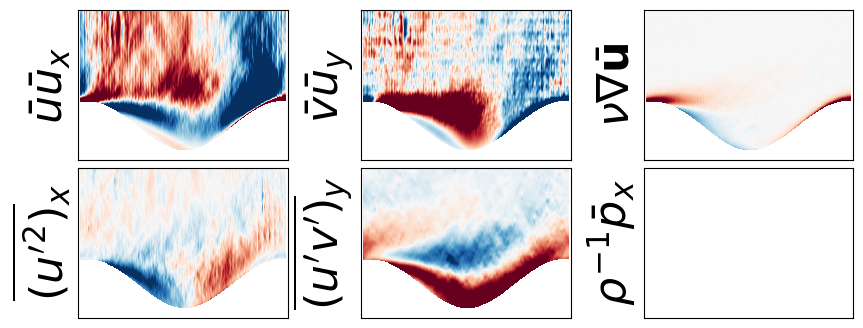

In [13]:
# Plot all six terms in the RANS equation
fig = plt.figure(figsize=(10, 4))
# labels = [r'$\bar{u} \bar{u}_x$', r'$\bar{v}\bar{u}_y$', r'$\rho^{-1} \bar{p}_x$',
#           r'$\nu \nabla^2 \bar{u}$', r'$\overline{(u^\prime v^\prime)}_y$', r'$\overline{({u^\prime} ^2)}_x$']
clim = 9e-1
fontsize=32

cmap = plt.colormaps['RdBu'].copy()
cmap.set_bad('white')

plt.subplot(231)
cluster_idx_to_fill = cluster_idx_im.copy().flatten()
indices = np.where(~np.isnan(cluster_idx_to_fill))
cluster_idx_to_fill[indices] = features[:,0]
cluster_idx_to_fill = np.reshape(cluster_idx_to_fill, (ny,nx))
plt.pcolormesh(xx,yy[:y_cutoff], cluster_idx_to_fill[:y_cutoff,:], vmin=-clim, vmax=clim, cmap=cmap)
plt.gca().set_xticks([])
plt.gca().set_yticks([])
plt.gca().set_facecolor('white')
plt.ylabel(labels[0], fontsize=fontsize)

plt.subplot(232)
# field = features[:,1]
cluster_idx_to_fill = cluster_idx_im.copy().flatten()
indices = np.where(~np.isnan(cluster_idx_to_fill))
cluster_idx_to_fill[indices] = features[:,1]
cluster_idx_to_fill = np.reshape(cluster_idx_to_fill, (ny,nx))
plt.pcolormesh(xx,yy[:y_cutoff], cluster_idx_to_fill[:y_cutoff,:], vmin=-clim, vmax=clim, cmap=cmap)
plt.gca().set_xticks([])
plt.gca().set_yticks([])
plt.gca().set_facecolor('white')
plt.ylabel(labels[1], fontsize=fontsize)

plt.subplot(233)
# field = features[:,2]
cluster_idx_to_fill = cluster_idx_im.copy().flatten()
indices = np.where(~np.isnan(cluster_idx_to_fill))
cluster_idx_to_fill[indices] = features[:,2]
cluster_idx_to_fill = np.reshape(cluster_idx_to_fill, (ny,nx))
plt.pcolormesh(xx,yy[:y_cutoff], cluster_idx_to_fill[:y_cutoff,:], vmin=-clim, vmax=clim, cmap=cmap)
plt.gca().set_xticks([])
plt.gca().set_yticks([])
plt.gca().set_facecolor('white')
plt.ylabel(labels[2], fontsize=fontsize)

plt.subplot(234)
# field = features[:,3]
cluster_idx_to_fill = cluster_idx_im.copy().flatten()
indices = np.where(~np.isnan(cluster_idx_to_fill))
cluster_idx_to_fill[indices] = features[:,3]
cluster_idx_to_fill = np.reshape(cluster_idx_to_fill, (ny,nx))
plt.pcolormesh(xx,yy[:y_cutoff], cluster_idx_to_fill[:y_cutoff,:], vmin=-clim, vmax=clim, cmap=cmap)
plt.gca().set_xticks([])
plt.gca().set_yticks([])
plt.gca().set_facecolor('white')
plt.ylabel(labels[3], fontsize=fontsize)

plt.subplot(235)
# field = features[:,4]
cluster_idx_to_fill = cluster_idx_im.copy().flatten()
indices = np.where(~np.isnan(cluster_idx_to_fill))
cluster_idx_to_fill[indices] = features[:,4]
cluster_idx_to_fill = np.reshape(cluster_idx_to_fill, (ny,nx))
plt.pcolormesh(xx,yy[:y_cutoff], cluster_idx_to_fill[:y_cutoff,:], vmin=-clim, vmax=clim, cmap=cmap)
plt.gca().set_xticks([])
plt.gca().set_yticks([])
plt.gca().set_facecolor('white')
plt.ylabel(labels[4], fontsize=fontsize)

plt.subplot(236)
# field = features[:,5]
# cluster_idx_to_fill = cluster_idx_im.copy().flatten()
# indices = np.where(~np.isnan(cluster_idx_to_fill))
# cluster_idx_to_fill[indices] = features[:,5]
# cluster_idx_to_fill = np.reshape(cluster_idx_to_fill, (ny,nx))
# plt.pcolormesh(xx,yy[:y_cutoff], cluster_idx_to_fill[:y_cutoff,:], vmin=-clim, vmax=clim, cmap=cmap)
plt.gca().set_xticks([])
plt.gca().set_yticks([])
plt.gca().set_facecolor('white')
plt.gca().patch.set_alpha(1.0)
plt.ylabel(labels[5], fontsize=fontsize)

fig.patch.set_alpha(0)


plt.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=0.35, hspace=0.05)

plt.savefig('PIVWavyWall_WeakTerms_PressLast.png')

plt.show()